In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Load Rhapsodie: extract per-style aggregate rows ---
df_rhap = pd.read_csv("results_rhap.csv")
df_rhap_styles = df_rhap[df_rhap['file'].str.startswith('STYLE')].copy()
df_rhap_styles['dataset'] = 'Rhapsodie'
df_rhap_styles['style'] = df_rhap_styles['style'].str.capitalize()

# --- Load Typaloc: one file per style ---
typaloc_files = {
    'CEREB': 'results_cereb.csv',
    'SLA':   'results_sla.csv',
    'PARK':  'results_park.csv',
    'CTRL':  'results_ctrl.csv',
}

typaloc_rows = []
for style_name, filepath in typaloc_files.items():
    df_tmp = pd.read_csv(filepath)
    global_row = df_tmp[df_tmp['file'] == 'GLOBAL'].copy()
    global_row['dataset'] = 'Typaloc'
    global_row['style']   = style_name  # ← inject style from dict key
    typaloc_rows.append(global_row)
df_typaloc_styles = pd.concat(typaloc_rows, ignore_index=True)

# --- Load Tapas: single global row, inject style ---
df_tapas = pd.read_csv("results_tapas.csv")
df_tapas_styles = df_tapas[df_tapas['file'] == 'GLOBAL'].copy()
df_tapas_styles['dataset'] = 'Tapas'
df_tapas_styles['style']   = 'Spont'  # ← inject style manually

# --- Combine ---
df_plot = pd.concat([df_rhap_styles, df_typaloc_styles, df_tapas_styles], ignore_index=True)

# Verify
print(df_plot[['dataset', 'style', '% within 20ms', '% within 50ms']].to_string())

df_plot.to_csv("all_data_results.csv")


FileNotFoundError: [Errno 2] No such file or directory: 'results_rhap.csv'

In [1]:
import os
import pandas as pd

systems = ["ctc_results", "mfa_results_w2vmfa", "mfa_results_asrw2v", 
           "mfa_results_gold", "mfa_results_goldphone"]

typaloc_styles = ["cereb", "sla", "ctrl", "park"]

all_dfs = []

for system in systems:
    
    # --- Rhapsodie: one CSV, styles as STYLE_ rows ---
    rhap_path = os.path.join(system, "results_rhap.csv")
    df_rhap = pd.read_csv(rhap_path)
    df_rhap = df_rhap[df_rhap['file'].str.startswith('STYLE')].copy()
    df_rhap['dataset'] = 'Rhapsodie'
    df_rhap['system']  = system
    all_dfs.append(df_rhap)

    # --- Typaloc: one CSV per style, use GLOBAL row ---
    for style in typaloc_styles:
        path = os.path.join(system, f"results_{style}.csv")
        df_tmp = pd.read_csv(path)
        global_row = df_tmp[df_tmp['file'] == 'GLOBAL'].copy()
        global_row['dataset'] = 'Typaloc'
        global_row['style']   = style.upper()
        global_row['system']  = system
        all_dfs.append(global_row)

    # --- Tapas: one CSV, use GLOBAL row ---
    tapas_path = os.path.join(system, "results_tapas.csv")
    df_tapas = pd.read_csv(tapas_path)
    global_row = df_tapas[df_tapas['file'] == 'GLOBAL'].copy()
    global_row['dataset'] = 'Tapas'
    global_row['style']   = 'Spont'
    global_row['system']  = system
    all_dfs.append(global_row)

# Combine
df_all = pd.concat(all_dfs, ignore_index=True)

# Clean up style column for Rhapsodie (STYLE_planned → Planned)
df_all['style'] = df_all['style'].str.replace('STYLE_', '', regex=False).str.capitalize()

# Keep only relevant columns
cols = ['system', 'dataset', 'style', 'N_ref', 'PER (%)', 
        'Median_start_error (ms)','Median_end_error (ms)','Median_mid_error (ms)', '% within 20ms', '% within 50ms',
        'F1@0ms (%)','F1@20ms (%)', 'F1@50ms (%)']
df_all = df_all[cols].reset_index(drop=True)

print(df_all)


                   system    dataset    style  N_ref    PER (%)  \
0             ctc_results  Rhapsodie  Planned  29234  11.811589   
1             ctc_results  Rhapsodie     Semi  14697  21.126761   
2             ctc_results  Rhapsodie    Spont  46184  20.201801   
3             ctc_results    Typaloc    Cereb   4642  26.691081   
4             ctc_results    Typaloc      Sla   6396  36.554096   
5             ctc_results    Typaloc     Ctrl   6826  18.766481   
6             ctc_results    Typaloc     Park   4571  23.955371   
7             ctc_results      Tapas    Spont  30592  18.197568   
8      mfa_results_w2vmfa  Rhapsodie  Planned  29234  11.811589   
9      mfa_results_w2vmfa  Rhapsodie     Semi  14697  21.126761   
10     mfa_results_w2vmfa  Rhapsodie    Spont  46184  20.201801   
11     mfa_results_w2vmfa    Typaloc    Cereb   4642  26.691081   
12     mfa_results_w2vmfa    Typaloc      Sla   6396  36.554096   
13     mfa_results_w2vmfa    Typaloc     Ctrl   6826  18.76648

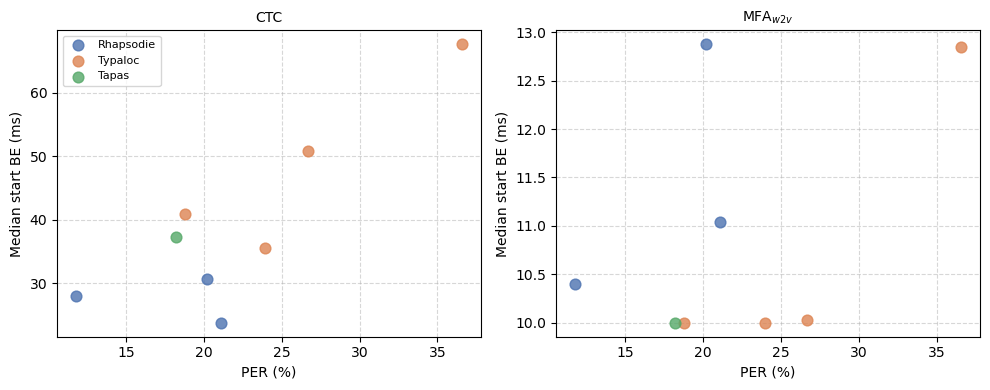

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

dataset_colors = {"Rhapsodie": "#4C72B0", "Typaloc": "#DD8452", "Tapas": "#55A868"}

for ax, sys_key, sys_label in zip(axes, 
    ["ctc_results", "mfa_results_w2vmfa"], ["CTC", "MFA$_{w2v}$"]):
    
    subset = df_all[df_all["system"] == sys_key]
    for ds, col in dataset_colors.items():
        rows = subset[subset["dataset"] == ds]
        ax.scatter(rows["PER (%)"], rows["Median_start_error (ms)"],
                   color=col, s=60, label=ds, alpha=0.8, zorder=3)
    
    ax.set_xlabel("PER (%)", fontsize=10)
    ax.set_ylabel("Median start BE (ms)", fontsize=10)
    ax.set_title(sys_label, fontsize=10)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.xaxis.grid(True, linestyle="--", alpha=0.5)
    if ax == axes[0]:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("per_vs_be_scatter.pdf", dpi=300, bbox_inches="tight")

In [6]:
import numpy as np
import pandas as pd

systems_order = ["ctc_results", "mfa_results_asrw2v", "mfa_results_gold",
                 "mfa_results_w2vmfa", "mfa_results_goldphone"]
sys_labels    = ["CTC", "MFA$_{asr}$", "MFA$_{gold}$",
                 "MFA$_{w2v}$", "MFA$_{goldphone}$"]

conditions = [
    ("Rhapsodie", "Planned"),
    ("Rhapsodie", "Semi"),
    ("Rhapsodie", "Spont"),
    ("Typaloc",   "Ctrl"),
    ("Typaloc",   "Park"),
    ("Typaloc",   "Cereb"),
    ("Typaloc",   "Sla"),
    ("Tapas",     "Spont"),
]
cond_labels = ["Planned", "Semi", "Spont", "Ctrl", "Park", "Cereb", "Sla", "Spont"]

# Build F1@50ms matrix
matrix_f1 = np.zeros((len(systems_order), len(conditions)))
for i, sys in enumerate(systems_order):
    for j, (ds, st) in enumerate(conditions):
        row = df_all[(df_all["system"]==sys) &
                     (df_all["dataset"]==ds) &
                     (df_all["style"]==st)]
        if len(row) > 0:
            matrix_f1[i, j] = row["F1@50ms (%)"].values[0]

# Build start BE matrix
matrix_be = np.zeros((len(systems_order), len(conditions)))
for i, sys in enumerate(systems_order):
    for j, (ds, st) in enumerate(conditions):
        row = df_all[(df_all["system"]==sys) &
                     (df_all["dataset"]==ds) &
                     (df_all["style"]==st)]
        if len(row) > 0:
            matrix_be[i, j] = row["Median_start_error (ms)"].values[0]

print("F1@50ms matrix:")
df_f1 = pd.DataFrame(matrix_f1, index=sys_labels, columns=cond_labels)
print(df_f1.round(1).to_string())

print("\nMedian start BE matrix:")
df_be = pd.DataFrame(matrix_be, index=sys_labels, columns=cond_labels)
print(df_be.round(1).to_string())

F1@50ms matrix:
                   Planned  Semi  Spont  Ctrl  Park  Cereb   Sla  Spont
CTC                   82.0  82.0   81.9  76.5  77.2   61.5  53.5   71.9
MFA$_{asr}$           78.4  76.5   75.8  80.0  73.2   63.5  49.9   74.3
MFA$_{gold}$          82.1  83.8   83.2  83.3  77.9   62.7  66.4   80.1
MFA$_{w2v}$           89.2  86.5   86.5  91.4  89.2   81.7  70.3   83.7
MFA$_{goldphone}$     91.7  92.3   91.4  92.7  92.4   83.1  76.4   88.2

Median start BE matrix:
                   Planned  Semi  Spont  Ctrl  Park  Cereb   Sla  Spont
CTC                   27.9  23.8   30.6  41.0  35.5   50.9  67.7   37.4
MFA$_{asr}$           11.1  11.4   13.4  10.0  10.0   12.1  43.0   10.0
MFA$_{gold}$          11.1  12.4   13.2  10.0  10.0  158.1  13.7   10.0
MFA$_{w2v}$           10.4  11.0   12.9  10.0  10.0   10.0  12.8   10.0
MFA$_{goldphone}$     10.2  11.4   12.6  10.0  10.0   10.6  12.6   10.0


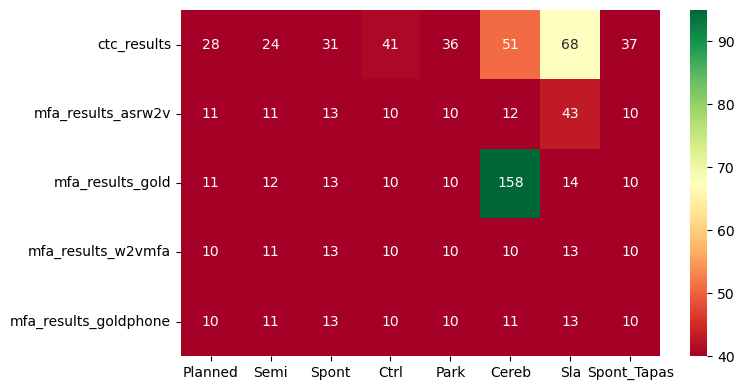

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(df_be, annot=True, fmt=".0f", cmap="RdYlGn",
            xticklabels=cond_order, yticklabels=systems_order,
            vmin=40, vmax=95, ax=ax)
plt.tight_layout()
plt.savefig("f1_heatmap.pdf", dpi=300, bbox_inches="tight")

In [10]:
import pickle
import numpy as np
import Levenshtein

def align_sequences(ref, hyp):
    alignment = []
    ops = Levenshtein.editops(ref, hyp)

    ref_idx = hyp_idx = 0
    op_idx = 0

    while ref_idx < len(ref) or hyp_idx < len(hyp):

        if op_idx < len(ops):
            op_type, src_pos, dest_pos = ops[op_idx]

            if op_type == "delete" and src_pos == ref_idx:
                alignment.append((ref_idx, None))
                ref_idx += 1
                op_idx += 1
                continue

            elif op_type == "insert" and dest_pos == hyp_idx:
                alignment.append((None, hyp_idx))
                hyp_idx += 1
                op_idx += 1
                continue

            elif op_type == "replace" and \
                 src_pos == ref_idx and \
                 dest_pos == hyp_idx:
                alignment.append((ref_idx, hyp_idx))
                ref_idx += 1
                hyp_idx += 1
                op_idx += 1
                continue

        # equal case
        if ref_idx < len(ref) and hyp_idx < len(hyp):
            alignment.append((ref_idx, hyp_idx))
            ref_idx += 1
            hyp_idx += 1
        elif ref_idx < len(ref):
            alignment.append((ref_idx, None))
            ref_idx += 1
        elif hyp_idx < len(hyp):
            alignment.append((None, hyp_idx))
            hyp_idx += 1

    return alignment
def match_alignments_lev(ref_alignments, hyp_alignments, ref_seq, hyp_seq,
                         max_time_diff=None):  # None = no filtering by default

    alignment = align_sequences(ref_seq, hyp_seq)#align_sequences_banded(ref_seq, hyp_seq, band=band)#

    start_errors = []
    end_errors = []
    duration_errors = []
    mid_errors = []
    matched_pairs = []
    filtered_count = 0

    for ref_idx, hyp_idx in alignment:

        if ref_idx is None or hyp_idx is None:
            continue

        if ref_seq[ref_idx] != hyp_seq[hyp_idx]:
            continue

        r_start = ref_alignments[ref_idx]["start"]
        r_end   = ref_alignments[ref_idx]["end"]
        h_start = hyp_alignments[hyp_idx]["start"]
        h_end   = hyp_alignments[hyp_idx]["end"]

        mid_ref  = (r_start + r_end) / 2
        mid_pred = (h_start + h_end) / 2
        mid_error = abs(mid_ref - mid_pred)

        if max_time_diff is not None and mid_error > max_time_diff:
            filtered_count += 1
            continue

        start_errors.append(abs(r_start - h_start))
        end_errors.append(abs(r_end - h_end))
        duration_errors.append(abs((r_end - r_start) - (h_end - h_start)))
        mid_errors.append(mid_error)
        matched_pairs.append((ref_idx, hyp_idx))

    return start_errors, end_errors, duration_errors, mid_errors, matched_pairs, filtered_count

for fname in ["Rhap-D2002.wav", "Rhap-D2005.wav", "Rhap-M2001.wav"]:
    ctc_hyp_start = store_ctc[fname]["hyp_intervals"][0]["start"]
    mfa_hyp_start = store_mfa[fname]["hyp_intervals"][0]["start"]
    ctc_ref_start = store_ctc[fname]["ref_intervals"][0]["start"]
    mfa_ref_start = store_mfa[fname]["ref_intervals"][0]["start"]
    print(f"{fname}:")
    print(f"  CTC  ref_start={ctc_ref_start:.3f}s  hyp_start={ctc_hyp_start:.3f}s  gap={ctc_ref_start-ctc_hyp_start:.3f}s")
    print(f"  MFA  ref_start={mfa_ref_start:.3f}s  hyp_start={mfa_hyp_start:.3f}s  gap={mfa_ref_start-mfa_hyp_start:.3f}s")

Rhap-D2002.wav:
  CTC  ref_start=0.000s  hyp_start=0.030s  gap=-0.030s
  MFA  ref_start=0.000s  hyp_start=0.000s  gap=0.000s
Rhap-D2005.wav:
  CTC  ref_start=0.000s  hyp_start=0.030s  gap=-0.030s
  MFA  ref_start=0.000s  hyp_start=0.000s  gap=0.000s
Rhap-M2001.wav:
  CTC  ref_start=0.000s  hyp_start=0.050s  gap=-0.050s
  MFA  ref_start=0.000s  hyp_start=0.000s  gap=0.000s


In [5]:
# Compare a few specific files to see if ref_seq is identical
import pickle

with open("mfa_results_w2vmfa/alignment_rhap.pkl", "rb") as f:
    store_w2v = pickle.load(f)

with open("mfa_results_goldphone/alignment_rhap.pkl", "rb") as f:
    store_gold = pickle.load(f)

# Pick one file and compare ref_seq and hyp_seq
sample_file = list(store_w2v.keys())[0]
print(f"File: {sample_file}")
print(f"w2vmfa   ref_seq[:10]: {store_w2v[sample_file]['ref_seq'][:10]}")
print(f"goldphone ref_seq[:10]: {store_gold[sample_file]['ref_seq'][:10]}")
print()
print(f"w2vmfa   hyp_seq[:10]: {store_w2v[sample_file]['hyp_seq'][:10]}")
print(f"goldphone hyp_seq[:10]: {store_gold[sample_file]['hyp_seq'][:10]}")

File: Rhap-D0003.wav
w2vmfa   ref_seq[:10]: ['v', 'u', 'z', 'ɛ', 't', 'v', 'ə', 'n', 'y', 'a']
goldphone ref_seq[:10]: ['v', 'u', 'z', 'ɛ', 't', 'v', 'ə', 'n', 'y', 'a']

w2vmfa   hyp_seq[:10]: ['v', 'u', 'z', 'ɛ', 't', 'v', 'ə', 'n', 'y', 'a']
goldphone hyp_seq[:10]: ['v', 'u', 'z', 'ɛ', 't', 'v', 'ə', 'n', 'y', 'a']


In [7]:
"""import pickle
import numpy as np
from metrics import *
import pickle
from jiwer import process_words

folders =["ctc_results","mfa_results_asrw2v","mfa_results_w2vmfa","mfa_results_gold","mfa_results_goldphone"]
for fi in folders:
    with open(f"{fi}/alignment_cereb.pkl", "rb") as f:
        store = pickle.load(f)
    metrics(store,f"{fi}/results_cereb.csv")"""



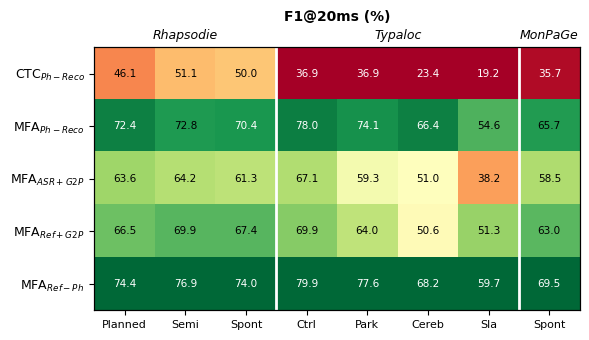

In [14]:
import matplotlib.pyplot as plt
import numpy as np

sys_labels  = ["CTC$_{Ph-Reco}$", "MFA$_{Ph-Reco}$", "MFA$_{ASR+G2P}$", "MFA$_{Ref+G2P}$", "MFA$_{Ref-Ph}$"]
cond_labels = ["Planned", "Semi", "Spont",
               "Ctrl", "Park", "Cereb", "Sla",
               "Spont"]
conditions = [
    ("Rhapsodie","Planned"), ("Rhapsodie","Semi"), ("Rhapsodie","Spont"),
    ("Typaloc","Ctrl"), ("Typaloc","Park"), ("Typaloc","Cereb"), ("Typaloc","Sla"),
    ("Tapas","Spont"),
]
systems = ["ctc_results","mfa_results_w2vmfa","mfa_results_asrw2v",
           "mfa_results_gold","mfa_results_goldphone"]

# Build matrix (F1@20ms only)
mat_20 = np.zeros((len(systems), len(conditions)))
for i, sys in enumerate(systems):
    for j, (ds, st) in enumerate(conditions):
        row = df_all[(df_all['system']==sys) &
                     (df_all['dataset']==ds) &
                     (df_all['style'].str.lower()==st.lower())]
        mat_20[i, j] = row['F1@20ms (%)'].values[0]

# Normalize each column by its maximum value
col_max = mat_20.max(axis=0, keepdims=True)  # shape (1, n_conditions)
mat_norm = mat_20 / col_max  # values in (0, 1]

fig, ax = plt.subplots(1, 1, figsize=(6, 3.5))

im = ax.imshow(mat_norm, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')

# Annotate with original values
for i in range(len(systems)):
    for j in range(len(conditions)):
        norm_val = mat_norm[i, j]
        ax.text(j, i, f"{mat_20[i,j]:.1f}", ha='center', va='center',
                fontsize=7.5,
                color='black' if 0.6 < norm_val < 0.95 else 'white')

ax.set_xticks(range(len(conditions)))
ax.set_xticklabels(cond_labels, fontsize=8)
ax.set_yticks(range(len(systems)))
ax.set_yticklabels(sys_labels, fontsize=9)
ax.set_title("F1@20ms (%)", fontsize=10, fontweight='bold')

# Dataset separator lines
for x_sep in [2.5, 6.5]:
    ax.axvline(x=x_sep, color='white', linewidth=2)

#plt.colorbar(im, ax=ax, shrink=0.8, label='Normalized by column max')

# Dataset labels on top
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([1.0, 4.5, 7.0])
ax2.set_xticklabels(["Rhapsodie", "Typaloc", "MonPaGe"], fontsize=9, style='italic')
ax2.tick_params(length=0)

plt.tight_layout()
plt.savefig("f1_heatmap.pdf", dpi=300, bbox_inches='tight')
plt.show()

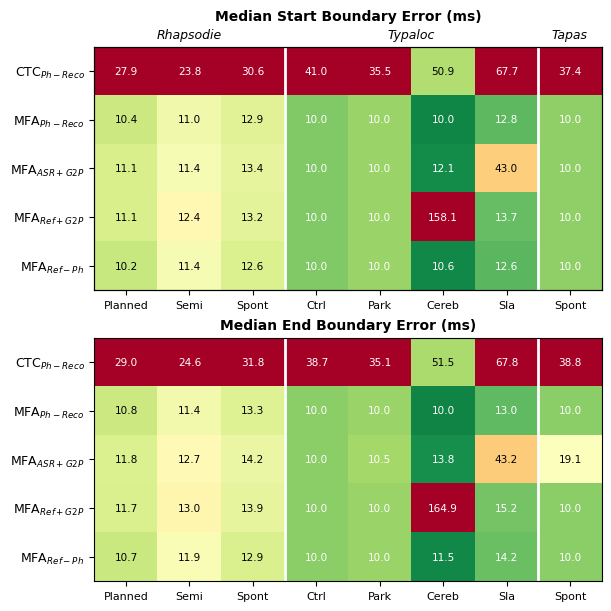

In [16]:
import matplotlib.pyplot as plt
import numpy as np

sys_labels  = ["CTC$_{Ph-Reco}$", "MFA$_{Ph-Reco}$", "MFA$_{ASR+G2P}$", "MFA$_{Ref+G2P}$", "MFA$_{Ref-Ph}$"]
cond_labels = ["Planned", "Semi", "Spont",
               "Ctrl", "Park", "Cereb", "Sla",
               "Spont"]
conditions = [
    ("Rhapsodie","Planned"), ("Rhapsodie","Semi"), ("Rhapsodie","Spont"),
    ("Typaloc","Ctrl"), ("Typaloc","Park"), ("Typaloc","Cereb"), ("Typaloc","Sla"),
    ("Tapas","Spont"),
]
systems = ["ctc_results","mfa_results_w2vmfa","mfa_results_asrw2v",
           "mfa_results_gold","mfa_results_goldphone"]

def build_matrix(col):
    mat = np.zeros((len(systems), len(conditions)))
    for i, sys in enumerate(systems):
        for j, (ds, st) in enumerate(conditions):
            row = df_all[(df_all['system']==sys) &
                         (df_all['dataset']==ds) &
                         (df_all['style'].str.lower()==st.lower())]
            mat[i, j] = row[col].values[0]
    return mat

mat_start = build_matrix('Median_start_error (ms)')
mat_end   = build_matrix('Median_end_error (ms)')

fig, axes = plt.subplots(2, 1, figsize=(6, 6), constrained_layout=True)

for ax, mat, title in zip(axes,
                           [mat_start, mat_end],
                           ["Median Start Boundary Error (ms)",
                            "Median End Boundary Error (ms)"]):

    col_max  = mat.max(axis=0, keepdims=True)
    mat_norm = mat / col_max

    im = ax.imshow(mat_norm, cmap='RdYlGn_r', vmin=0, vmax=1, aspect='auto')

    for i in range(len(systems)):
        for j in range(len(conditions)):
            norm_val = mat_norm[i, j]
            ax.text(j, i, f"{mat[i,j]:.1f}", ha='center', va='center',
                    fontsize=7.5,
                    color='white' if norm_val > 0.7 or norm_val < 0.3 else 'black')

    ax.set_xticks(range(len(conditions)))
    ax.set_xticklabels(cond_labels, fontsize=8)
    ax.set_yticks(range(len(systems)))
    ax.set_yticklabels(sys_labels, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')

    for x_sep in [2.5, 6.5]:
        ax.axvline(x=x_sep, color='white', linewidth=2)

    # Dataset labels on top — only for first subplot
    if ax is axes[0]:
        ax2 = ax.twiny()
        ax2.set_xlim(ax.get_xlim())
        ax2.set_xticks([1.0, 4.5, 7.0])
        ax2.set_xticklabels(["Rhapsodie", "Typaloc", "Tapas"], fontsize=9, style='italic')
        ax2.tick_params(length=0)

plt.savefig("BE_heatmap.pdf", dpi=300, bbox_inches='tight')
plt.show()

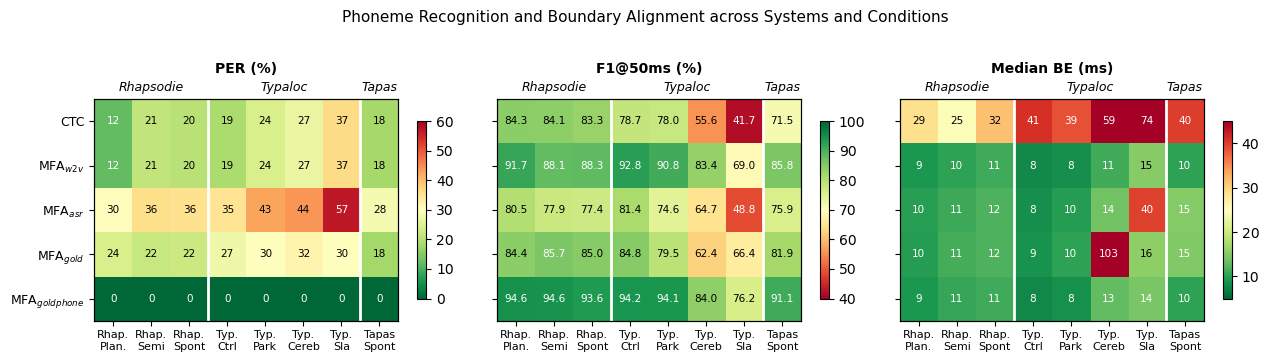

In [13]:
import matplotlib.pyplot as plt
import numpy as np

sys_labels  = ["CTC", "MFA$_{w2v}$", "MFA$_{asr}$", 
               "MFA$_{gold}$", "MFA$_{goldphone}$"]
cond_labels = ["Rhap.\nPlan.", "Rhap.\nSemi", "Rhap.\nSpont",
               "Typ.\nCtrl", "Typ.\nPark", "Typ.\nCereb", "Typ.\nSla",
               "Tapas\nSpont"]

conditions = [
    ("Rhapsodie","Planned"), ("Rhapsodie","Semi"), ("Rhapsodie","Spont"),
    ("Typaloc","Ctrl"), ("Typaloc","Park"), ("Typaloc","Cereb"), ("Typaloc","Sla"),
    ("Tapas","Spont"),
]
systems = ["ctc_results","mfa_results_w2vmfa","mfa_results_asrw2v",
           "mfa_results_gold","mfa_results_goldphone"]

# Build matrices
mat_per    = np.zeros((len(systems), len(conditions)))
mat_f1_50  = np.zeros((len(systems), len(conditions)))
mat_mbe    = np.zeros((len(systems), len(conditions)))

for i, sys in enumerate(systems):
    for j, (ds, st) in enumerate(conditions):
        row = df_all[(df_all['system']==sys) &
                     (df_all['dataset']==ds) &
                     (df_all['style'].str.lower()==st.lower())]
        mat_per[i, j]   = row['PER (%)'].values[0]
        mat_f1_50[i, j] = row['F1@50ms (%)'].values[0]
        mat_mbe[i, j]   = row['Median_mid_error (ms)'].values[0]

# PER and MBE: lower is better → reverse colormap
# F1: higher is better → normal colormap
metrics = [
    (mat_per,   "PER (%)",          'RdYlGn_r', 0,   60),
    (mat_f1_50, "F1@50ms (%)",      'RdYlGn',   40, 100),
    (mat_mbe,   "Median BE (ms)",   'RdYlGn_r', 5,   45),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

for ax, (mat, title, cmap, vmin, vmax) in zip(axes, metrics):
    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')

    for i in range(len(systems)):
        for j in range(len(conditions)):
            val = mat[i, j]
            # Format: integers for PER and MBE, 1 decimal for F1
            txt = f"{val:.0f}" if title != "F1@50ms (%)" else f"{val:.1f}"
            # White text on dark cells, black on light
            norm_val = (val - vmin) / (vmax - vmin)
            color = 'white' if norm_val < 0.25 or norm_val > 0.75 else 'black'
            ax.text(j, i, txt, ha='center', va='center', fontsize=7.5, color=color)

    ax.set_xticks(range(len(conditions)))
    ax.set_xticklabels(cond_labels, fontsize=8)
    ax.set_yticks(range(len(systems)))
    ax.set_yticklabels(sys_labels if ax == axes[0] else [], fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')

    # Dataset separators
    for x_sep in [2.5, 6.5]:
        ax.axvline(x=x_sep, color='white', linewidth=2)

    plt.colorbar(im, ax=ax, shrink=0.8)

    # Dataset labels on top
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    ax2.set_xticks([1.0, 4.5, 7.0])
    ax2.set_xticklabels(["Rhapsodie", "Typaloc", "Tapas"], fontsize=9, style='italic')
    ax2.tick_params(length=0)

fig.suptitle("Phoneme Recognition and Boundary Alignment across Systems and Conditions",
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("metrics_heatmap.pdf", dpi=300, bbox_inches='tight')
plt.show()

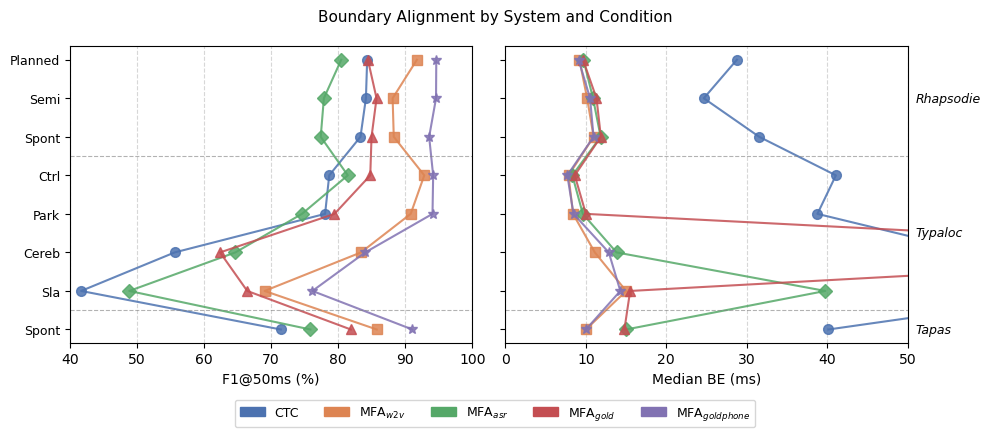

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

systems = ["ctc_results","mfa_results_w2vmfa","mfa_results_asrw2v",
           "mfa_results_gold","mfa_results_goldphone"]
sys_labels = ["CTC", "MFA$_{w2v}$", "MFA$_{asr}$", 
              "MFA$_{gold}$", "MFA$_{goldphone}$"]
colors = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"]
markers = ["o","s","D","^","*"]

conditions = [
    ("Rhapsodie","Planned"), ("Rhapsodie","Semi"), ("Rhapsodie","Spont"),
    ("Typaloc","Ctrl"), ("Typaloc","Park"), ("Typaloc","Cereb"), ("Typaloc","Sla"),
    ("Tapas","Spont"),
]
cond_labels = ["Planned","Semi","Spont","Ctrl","Park","Cereb","Sla","Spont"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

for i, (sys, lbl, col, mk) in enumerate(zip(systems, sys_labels, colors, markers)):
    f1_50 = []
    mbe   = []
    for ds, st in conditions:
        row = df_all[(df_all['system']==sys) &
                     (df_all['dataset']==ds) &
                     (df_all['style'].str.lower()==st.lower())]
        f1_50.append(row['F1@50ms (%)'].values[0])
        mbe.append(row['Median_mid_error (ms)'].values[0])

    y = np.arange(len(conditions))
    ax1.plot(f1_50, y, marker=mk, color=col, label=lbl, linewidth=1.5,
             markersize=7, linestyle='-', alpha=0.85)
    ax2.plot(mbe,   y, marker=mk, color=col, label=lbl, linewidth=1.5,
             markersize=7, linestyle='-', alpha=0.85)

# Formatting ax1 — F1@50ms
ax1.set_xlabel("F1@50ms (%)", fontsize=10)
ax1.set_xlim(40, 100)
ax1.set_yticks(range(len(conditions)))
ax1.set_yticklabels(cond_labels, fontsize=9)
ax1.xaxis.grid(True, linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)
ax1.invert_yaxis()

# Formatting ax2 — Median BE
ax2.set_xlabel("Median BE (ms)", fontsize=10)
ax2.set_xlim(0, 50)
ax2.set_yticks(range(len(conditions)))
ax2.set_yticklabels([], fontsize=9)
ax2.xaxis.grid(True, linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)
ax2.invert_yaxis()

# Dataset separators — horizontal lines between datasets
for ax in [ax1, ax2]:
    ax.axhline(y=2.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.axhline(y=6.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# Dataset labels on right side
for y_pos, label in [(1.0, "Rhapsodie"), (4.5, "Typaloc"), (7.0, "Tapas")]:
    ax2.text(51, y_pos, label, va='center', fontsize=9,
             style='italic', ha='left', clip_on=False)

# Legend
handles = [mpatches.Patch(color=c, label=l) 
           for c, l in zip(colors, sys_labels)]
fig.legend(handles=handles, loc='lower center', ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.08))

fig.suptitle("Boundary Alignment by System and Condition", fontsize=11)
plt.tight_layout()
plt.savefig("alignment_dotplot.pdf", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3133000/444280730.py:69: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


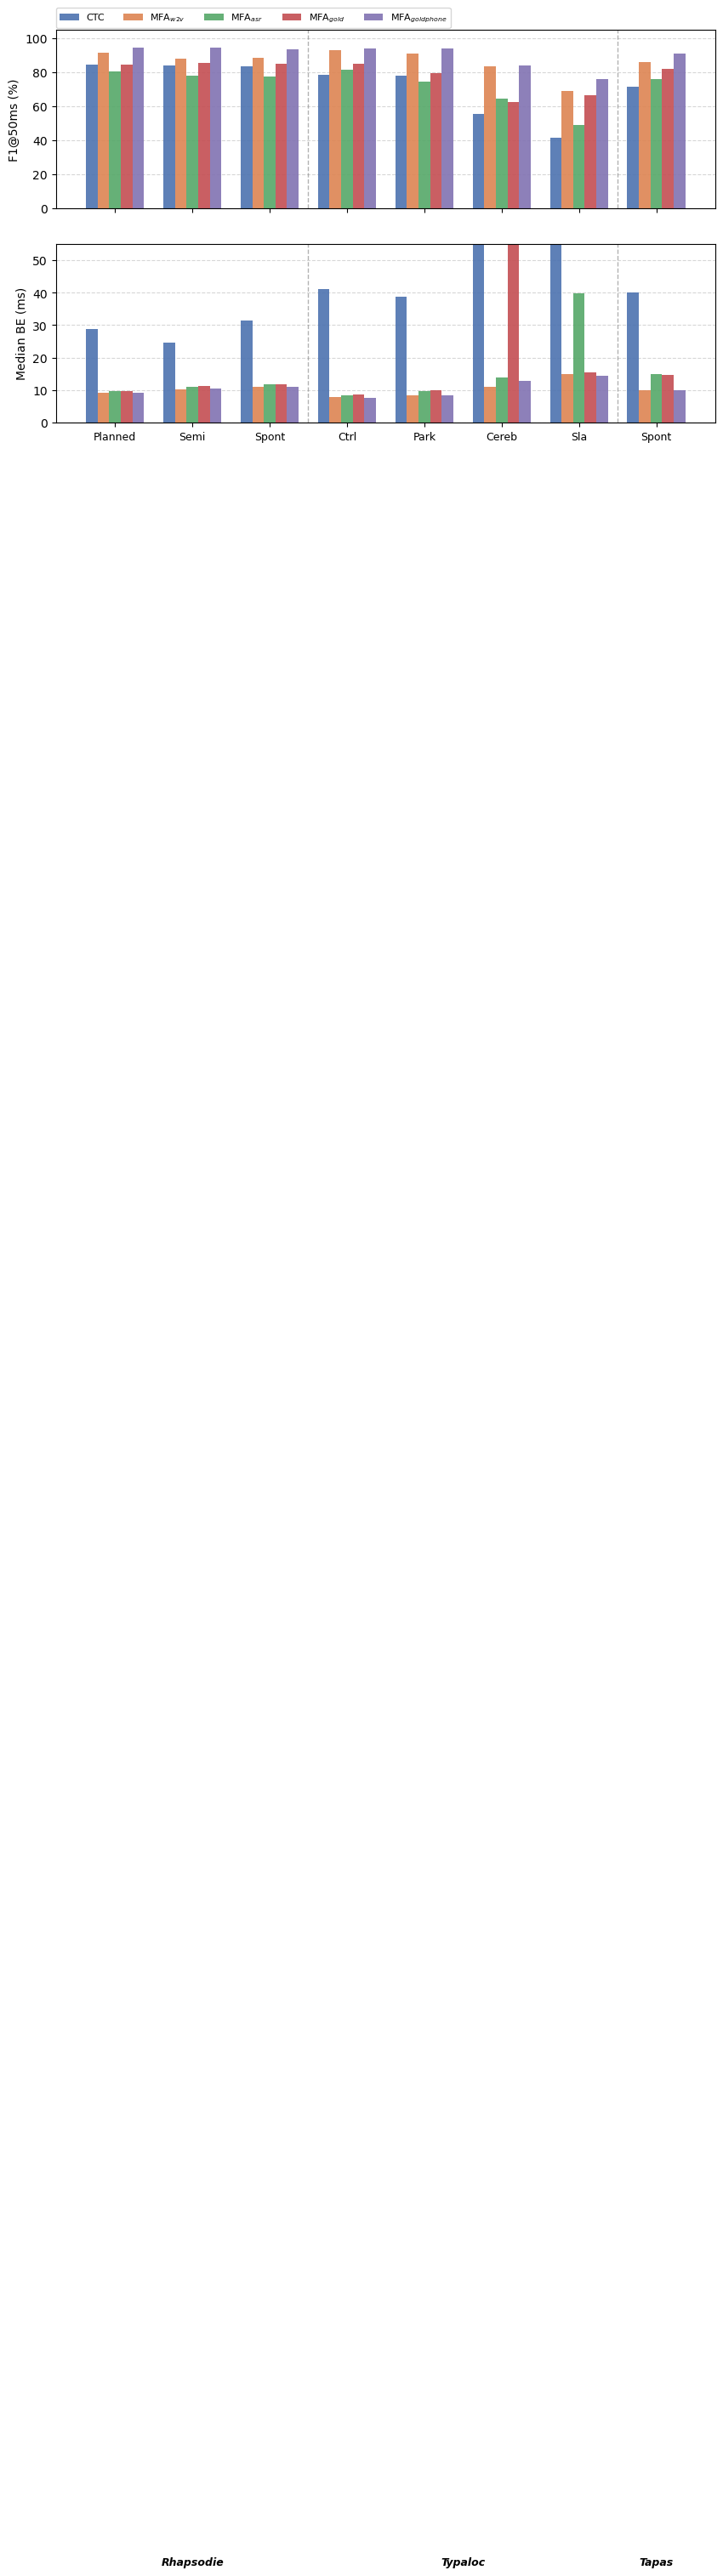

In [15]:
import matplotlib.pyplot as plt
import numpy as np

systems    = ["ctc_results","mfa_results_w2vmfa","mfa_results_asrw2v",
              "mfa_results_gold","mfa_results_goldphone"]
sys_labels = ["CTC","MFA$_{w2v}$","MFA$_{asr}$","MFA$_{gold}$","MFA$_{goldphone}$"]
colors     = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2"]

conditions  = [
    ("Rhapsodie","Planned"),("Rhapsodie","Semi"),("Rhapsodie","Spont"),
    ("Typaloc","Ctrl"),("Typaloc","Park"),("Typaloc","Cereb"),("Typaloc","Sla"),
    ("Tapas","Spont"),
]
cond_labels = ["Planned","Semi","Spont","Ctrl","Park","Cereb","Sla","Spont"]

n_cond = len(conditions)
n_sys  = len(systems)
x      = np.arange(n_cond)
width  = 0.15

# Build data
f1_50_data = np.zeros((n_sys, n_cond))
mbe_data   = np.zeros((n_sys, n_cond))

for i, sys in enumerate(systems):
    for j, (ds, st) in enumerate(conditions):
        row = df_all[(df_all['system']==sys) &
                     (df_all['dataset']==ds) &
                     (df_all['style'].str.lower()==st.lower())]
        f1_50_data[i,j] = row['F1@50ms (%)'].values[0]
        mbe_data[i,j]   = row['Median_mid_error (ms)'].values[0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

for i, (lbl, col) in enumerate(zip(sys_labels, colors)):
    offset = (i - n_sys/2 + 0.5) * width
    ax1.bar(x + offset, f1_50_data[i], width, label=lbl, color=col, alpha=0.9)
    ax2.bar(x + offset, mbe_data[i],   width, label=lbl, color=col, alpha=0.9)

# ax1 — F1@50ms
ax1.set_ylabel("F1@50ms (%)", fontsize=10)
ax1.set_ylim(0, 105)
ax1.yaxis.grid(True, linestyle='--', alpha=0.5)
ax1.set_axisbelow(True)
ax1.legend(fontsize=8, ncol=5, loc='lower left',
           bbox_to_anchor=(0, 1.01), borderaxespad=0)

# ax2 — Median BE
ax2.set_ylabel("Median BE (ms)", fontsize=10)
ax2.set_ylim(0, 55)
ax2.yaxis.grid(True, linestyle='--', alpha=0.5)
ax2.set_axisbelow(True)

# x-axis labels
ax2.set_xticks(x)
ax2.set_xticklabels(cond_labels, fontsize=9)

# Dataset separators and labels
for ax in [ax1, ax2]:
    ax.axvline(x=2.5,  color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.axvline(x=6.5,  color='gray', linestyle='--', linewidth=1, alpha=0.6)

# Dataset group labels below x-axis
for pos, label in [(1.0, "Rhapsodie"), (4.5, "Typaloc"), (7.0, "Tapas")]:
    ax2.text(pos, -12, label, ha='center', fontsize=9,
             fontweight='bold', style='italic',
             transform=ax2.get_xaxis_transform(), clip_on=False)

plt.tight_layout()
plt.savefig("alignment_bars.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [31]:
import pandas as pd
import glob
import os

# folder containing your result files
results_dir = "./"

# find all files starting with "results"
files = glob.glob(os.path.join(results_dir, "results*.csv"))
# read and concatenate
df_list = []

for f in files:
    df = pd.read_csv(f)
    
    dataset_name = os.path.basename(f).replace(".csv", "").split("_")[1]
    df["dataset"] = dataset_name
    
    df_list.append(df)
combined_df = pd.concat(df_list, ignore_index=True)

# save
combined_df.to_csv(os.path.join(results_dir, "all_results_combined.csv"), index=False)

print("Combined", len(files), "files.")

Combined 6 files.


In [32]:
combined_df

,Unnamed: 0,style,PER (%),Substitutions,Deletions,Insertions,N_ref,Mean_midpoint_error (ms),Median_midpoint_error (ms),Max_midpoint_error (ms),% within 20ms,% within 50ms,F1@50ms,dataset,Precision@50ms (%),Recall@50ms (%),F1@50ms (%),Corpus PER (%),% within 20ms (midpoint),% within 50ms (midpoint)
0,0,spont,21.054244,3294.0,6105.0,910.0,48964.0,195.089512,31.009594,53563.094939,36.838114,61.923417,80.758737,rhap,NaN,NaN,NaN,NaN,NaN,NaN
1,1,planned,11.811589,1367.0,1675.0,411.0,29234.0,76.609938,42.130499,5536.340391,29.608277,55.093158,83.315852,rhap,NaN,NaN,NaN,NaN,NaN,NaN
2,2,semi,21.126761,845.0,1892.0,368.0,14697.0,375.591908,132.914447,10293.331307,1.387960,8.269231,72.278436,rhap,NaN,NaN,NaN,NaN,NaN,NaN
3,0,NaN,NaN,NaN,NaN,NaN,NaN,1373.111006,71.812100,NaN,NaN,NaN,NaN,cereb,60.826636,57.065920,58.886295,26.691081,10.075567,32.801567
4,0,NaN,NaN,NaN,NaN,NaN,NaN,462.405061,68.651063,NaN,NaN,NaN,NaN,sla,59.075556,51.954346,55.286582,36.554096,15.323930,35.978962
5,0,NaN,NaN,NaN,NaN,NaN,NaN,540.564522,32.873429,NaN,NaN,NaN,NaN,park,79.597438,76.132137,77.826233,23.955371,34.792244,62.770083
6,0,NaN,NaN,NaN,NaN,NaN,NaN,925.299501,62.470497,NaN,NaN,NaN,NaN,ctrl,73.767526,71.681805,72.709711,18.766481,20.506154,44.583117
7,0,NaN,NaN,NaN,NaN,NaN,NaN,290.470953,50.373245,NaN,NaN,NaN,NaN,tapas,73.344376,70.920502,72.112077,18.197568,22.245997,49.730618


In [33]:
df=combined_df
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
style_df = df[df["style"].notna()].copy()
corpus_df = df[df["style"].isna()].copy()
style_clean = style_df[[
    "dataset",
    "style",
    "PER (%)",
    "Mean_midpoint_error (ms)",
    "Median_midpoint_error (ms)",
    "F1@50ms"
]].copy()

style_clean = style_clean.rename(columns={
    "F1@50ms": "F1@50ms (%)"
})
corpus_clean = corpus_df[[
    "dataset",
    "Precision@50ms (%)",
    "Recall@50ms (%)",
    "F1@50ms (%)",
    "Corpus PER (%)",
    "Mean_midpoint_error (ms)",
    "Median_midpoint_error (ms)"
]].copy()
corpus_clean["style"] = "global"
corpus_clean = corpus_clean[[
    "dataset",
    "style",
    "Corpus PER (%)",
    "Mean_midpoint_error (ms)",
    "Median_midpoint_error (ms)",
    "F1@50ms (%)"
]]

corpus_clean = corpus_clean.rename(columns={
    "Corpus PER (%)": "PER (%)"
})
clean_df = pd.concat([style_clean, corpus_clean], ignore_index=True)

clean_df = clean_df.sort_values(["dataset", "style"])
df=clean_df
df["original_dataset"] = df["dataset"]

df["dataset"] = df["dataset"].replace({
    "rhap": "Rhapsodie",
    "tapas": "Tapas",
    "cereb": "Typaloc",
    "park": "Typaloc",
    "sla": "Typaloc",
    "ctrl": "Typaloc"
})

mask_typaloc = df["dataset"] == "Typaloc"
df.loc[mask_typaloc, "style"] = df.loc[mask_typaloc, "original_dataset"].str.upper()

mask_tapas = df["dataset"] == "Tapas"
df.loc[mask_tapas, "style"] = "Spont"

df["style"] = df["style"].replace({
    "spont": "Spont",
    "semi": "Semi",
    "planned": "Planned"
})

df = df.drop(columns=["original_dataset"])
df = df.reset_index(drop=True)

row_to_move = df.iloc[6].copy()   # line 5
df = df.drop(index=6)
# Insert at position 1 (line 2)
upper = df.iloc[:1]
lower = df.iloc[1:]
df = pd.concat([upper, pd.DataFrame([row_to_move]), lower])



# Reset index
df = df.reset_index(drop=True)
df

,dataset,style,PER (%),Mean_midpoint_error (ms),Median_midpoint_error (ms),F1@50ms (%)
0,Typaloc,CEREB,26.691081,1373.111006,71.812100,58.886295
1,Typaloc,SLA,36.554096,462.405061,68.651063,55.286582
2,Typaloc,CTRL,18.766481,925.299501,62.470497,72.709711
3,Typaloc,PARK,23.955371,540.564522,32.873429,77.826233
4,Rhapsodie,Planned,11.811589,76.609938,42.130499,83.315852
5,Rhapsodie,Semi,21.126761,375.591908,132.914447,72.278436
6,Rhapsodie,Spont,21.054244,195.089512,31.009594,80.758737
7,Tapas,Spont,18.197568,290.470953,50.373245,72.112077


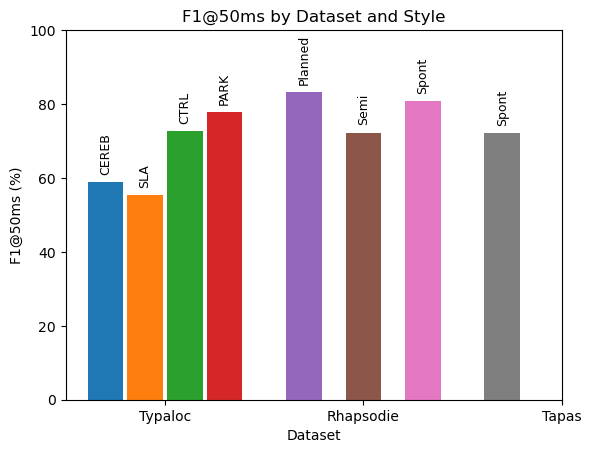

In [35]:
import numpy as np
import matplotlib.pyplot as plt

datasets = df["dataset"].unique()

x_positions = np.arange(len(datasets))
bar_width = 0.18

plt.figure()

for i, dataset in enumerate(datasets):
    
    subset = df[df["dataset"] == dataset]
    f1_values = subset["F1@50ms (%)"].values
    styles = subset["style"].values
    n_bars = len(f1_values)
    
    offsets = np.linspace(-0.3, 0.3, n_bars)
    
    for j in range(n_bars):
        x = x_positions[i] + offsets[j]
        y = f1_values[j]
        
        plt.bar(x, y, width=bar_width)
        
        # Annotate with style name
        plt.text(
            x,
            y + 2,                # small vertical offset
            styles[j],
            ha='center',
            va='bottom',
            rotation=90,          # vertical label
            fontsize=9
        )

plt.xticks(x_positions, datasets)
plt.ylabel("F1@50ms (%)")
plt.xlabel("Dataset")
plt.title("F1@50ms by Dataset and Style")
plt.ylim(0, 100)

plt.show()

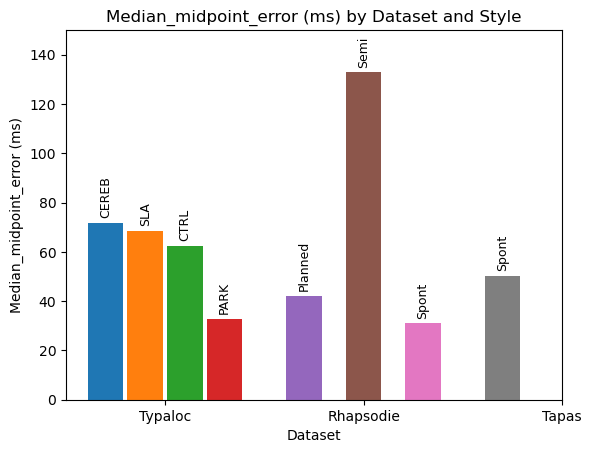

In [37]:
x_positions = np.arange(len(datasets))
bar_width = 0.18

plt.figure()

for i, dataset in enumerate(datasets):
    
    subset = df[df["dataset"] == dataset]
    f1_values = subset["Median_midpoint_error (ms)"].values
    styles = subset["style"].values
    n_bars = len(f1_values)
    
    offsets = np.linspace(-0.3, 0.3, n_bars)
    
    for j in range(n_bars):
        x = x_positions[i] + offsets[j]
        y = f1_values[j]
        
        plt.bar(x, y, width=bar_width)
        
        # Annotate with style name
        plt.text(
            x,
            y + 2,                # small vertical offset
            styles[j],
            ha='center',
            va='bottom',
            rotation=90,          # vertical label
            fontsize=9
        )

plt.xticks(x_positions, datasets)
plt.ylabel("Median_midpoint_error (ms)")
plt.xlabel("Dataset")
plt.title("Median_midpoint_error (ms) by Dataset and Style")
plt.ylim(0, 150)

plt.show()